# SWYNEX Technologies - Task 2
## Exploratory Data Analysis (EDA)

**Internship:** Data Analyst Internship  
**Company:** SWYNEX Technologies  
**Task:** Task 2 - Exploratory Data Analysis  
**Dataset:** Netflix Movies and TV Shows  
**Tools:** Python, Pandas, Matplotlib, Jupyter Notebook

## 1. Project Objective

The objective of this task is to perform Exploratory Data Analysis (EDA) on the cleaned Netflix Movies and TV Shows dataset prepared in Task 1.

The analysis focuses on:

- Understanding the structure and characteristics of the dataset
- Calculating important descriptive statistics
- Identifying trends and patterns
- Detecting unusual or noteworthy observations
- Creating meaningful visualizations
- Extracting useful insights from the data

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("Libraries imported successfully.")

Libraries imported successfully.


In [29]:
import pandas as pd

INPUT = r"D:\DATA ANALYTICS VIRTUAL INTERNSHIP\SWYNEX TECHNOLOGY  INTERNSHIP\DATA\netflix_titles_cleaned.csv"

df = pd.read_csv(INPUT)

print("Cleaned dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Cleaned dataset loaded successfully.
Rows: 8807
Columns: 12


In [30]:
# Basic dataset overview

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Records:")
display(df.head())

Dataset Shape: (8807, 12)

Column Names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Data Types:
show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

First 5 Records:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [31]:
# Descriptive statistics for numerical columns

print("Descriptive Statistics")
display(df.describe())

Descriptive Statistics


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [32]:
# Categorical Data Summary

categorical_columns = [
    "show_id",
    "type",
    "title",
    "director",
    "cast",
    "country",
    "date_added",
    "rating",
    "duration",
    "listed_in",
    "description"
]

summary = []

for column in categorical_columns:
    non_null_count = df[column].notna().sum()
    unique_values = df[column].nunique(dropna=True)
    
    value_counts = df[column].value_counts(dropna=True)
    
    if len(value_counts) > 0:
        most_frequent_value = value_counts.index[0]
        frequency = value_counts.iloc[0]
    else:
        most_frequent_value = "N/A"
        frequency = 0
    
    summary.append({
        "Column": column,
        "Non-Null Count": non_null_count,
        "Unique Values": unique_values,
        "Most Frequent Value": most_frequent_value,
        "Frequency": frequency
    })

categorical_summary = pd.DataFrame(summary)

print("Categorical Data Summary")
display(categorical_summary)

Categorical Data Summary


,Column,Non-Null Count,Unique Values,Most Frequent Value,Frequency
0,show_id,8807,8807,s1,1
1,type,8807,2,Movie,6131
2,title,8807,8806,Consequences,2
3,director,6173,4528,Rajiv Chilaka,19
4,cast,7982,7692,David Attenborough,19
5,country,7976,748,United States,2818
6,date_added,8797,1714,2020-01-01,110
7,rating,8800,14,TV-MA,3207
8,duration,8807,220,1 Season,1793
9,listed_in,8807,514,"Dramas, International Movies",362


## 4. Content Type Distribution

The dataset contains two main content types: Movies and TV Shows.

This analysis compares their distribution in the Netflix catalog.

# Count of Movies and TV Shows

type_counts = df["type"].value_counts()

print("Content Type Counts:")
display(type_counts.to_frame(name="Count"))

Content Type Counts:


,Count
type,
Movie,6131
TV Show,2676


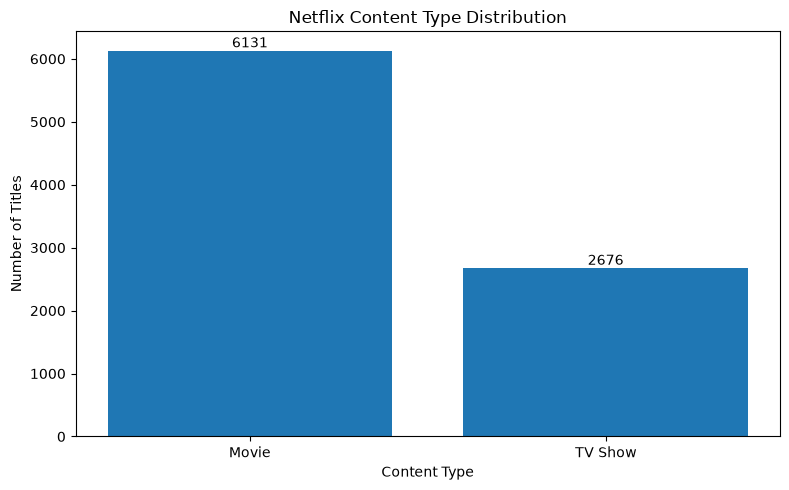

In [33]:
# Content Type Distribution

import matplotlib.pyplot as plt

# Calculate content type counts
type_counts = df["type"].value_counts()

# Display counts
print("Content Type Counts:")
display(type_counts.to_frame(name="Count"))

# Create chart
plt.figure(figsize=(8, 5))
plt.bar(type_counts.index, type_counts.values)

plt.title("Netflix Content Type Distribution")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

# Add values on top of bars
for i, value in enumerate(type_counts.values):
    plt.text(i, value, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.show()

## 5. Content Release Year Analysis

This analysis examines the distribution of Netflix titles across release years to identify major trends in content production and availability.

Release Year Analysis:


,Number of Titles
release_year,
1925,1
1942,2
1943,3
1944,3
1945,4
1946,2
1947,1
1954,2
1955,3


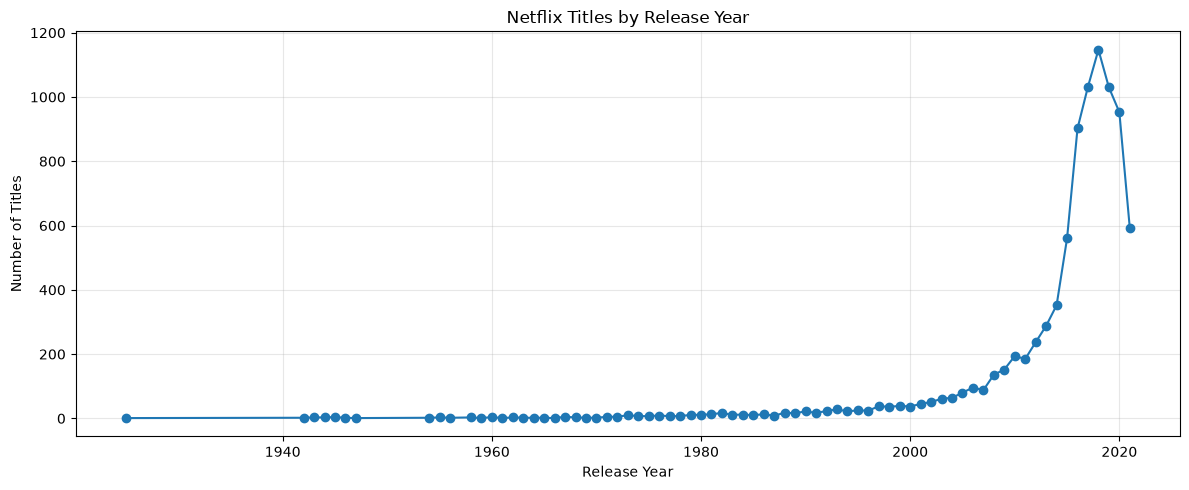

In [34]:
# Release Year Analysis

import matplotlib.pyplot as plt

# Count titles by release year
release_year_counts = df["release_year"].value_counts().sort_index()

# Display the first few results
print("Release Year Analysis:")
display(release_year_counts.head(10).to_frame(name="Number of Titles"))

# Plot the trend
plt.figure(figsize=(12, 5))

plt.plot(
    release_year_counts.index,
    release_year_counts.values,
    marker="o"
)

plt.title("Netflix Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Top 10 Release Years by Number of Titles

This analysis identifies the ten release years with the highest number of titles in the dataset.

Top 10 Release Years:


,Number of Titles
release_year,
2012,237
2013,288
2014,352
2015,560
2016,902
2017,1032
2018,1147
2019,1030
2020,953


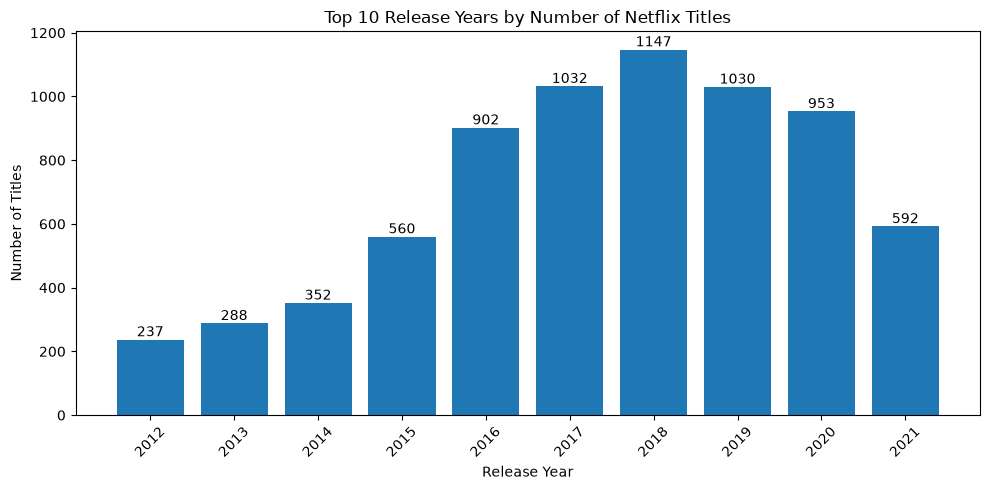

In [35]:
# Top 10 Release Years

import matplotlib.pyplot as plt

top_release_years = (
    df["release_year"]
    .value_counts()
    .sort_values(ascending=False)
    .head(10)
    .sort_index()
)

print("Top 10 Release Years:")
display(top_release_years.to_frame(name="Number of Titles"))

# Create chart
plt.figure(figsize=(10, 5))

plt.bar(
    top_release_years.index.astype(str),
    top_release_years.values
)

plt.title("Top 10 Release Years by Number of Netflix Titles")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

# Add values on bars
for i, value in enumerate(top_release_years.values):
    plt.text(i, value, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.show()

## 7. Rating Distribution Analysis

This analysis examines the distribution of content ratings to understand which rating categories are most common in the dataset.

Rating Distribution:


,Number of Titles
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


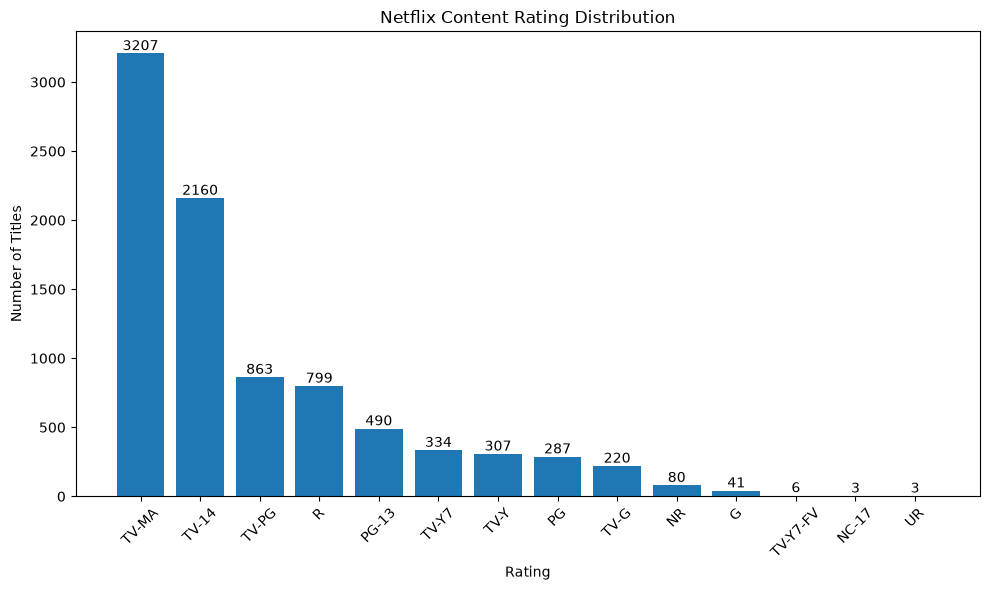

In [36]:
# Rating Distribution Analysis

import matplotlib.pyplot as plt

rating_counts = df["rating"].value_counts(dropna=True)

print("Rating Distribution:")
display(rating_counts.to_frame(name="Number of Titles"))

# Create chart
plt.figure(figsize=(10, 6))

plt.bar(
    rating_counts.index.astype(str),
    rating_counts.values
)

plt.title("Netflix Content Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

# Add values on bars
for i, value in enumerate(rating_counts.values):
    plt.text(i, value, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.show()

## 8. Top 10 Countries by Number of Titles

This analysis identifies the countries most frequently associated with titles in the Netflix dataset.

Because some records contain multiple countries, the country values are split before counting to provide a more meaningful country-level analysis.

Top 10 Countries by Number of Titles:


,Number of Titles
country,
United States,3690
India,1046
United Kingdom,806
Canada,445
France,393
Japan,318
Spain,232
South Korea,231
Germany,226


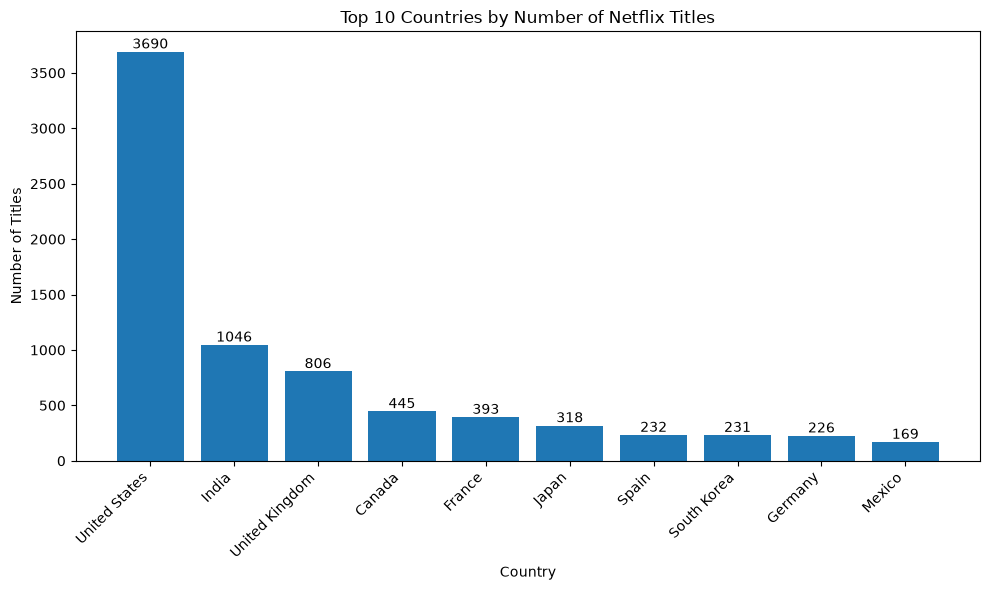

In [37]:
# Top 10 Countries Analysis

import matplotlib.pyplot as plt

# Remove missing country values and split multiple countries
country_series = (
    df["country"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
)

# Count countries
country_counts = country_series.value_counts().head(10)

print("Top 10 Countries by Number of Titles:")
display(country_counts.to_frame(name="Number of Titles"))

# Create chart
plt.figure(figsize=(10, 6))

plt.bar(
    country_counts.index,
    country_counts.values
)

plt.title("Top 10 Countries by Number of Netflix Titles")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45, ha="right")

# Add values on bars
for i, value in enumerate(country_counts.values):
    plt.text(i, value, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.show()

## 9. Movie Duration Analysis

This analysis examines the duration of Netflix movies to understand the typical movie length and identify the most common duration range.

Movie Duration Statistics:


,Duration (minutes)
count,6131.000000
mean,99.564998
std,28.289504
min,3.000000
25%,87.000000
50%,98.000000
75%,114.000000
max,312.000000


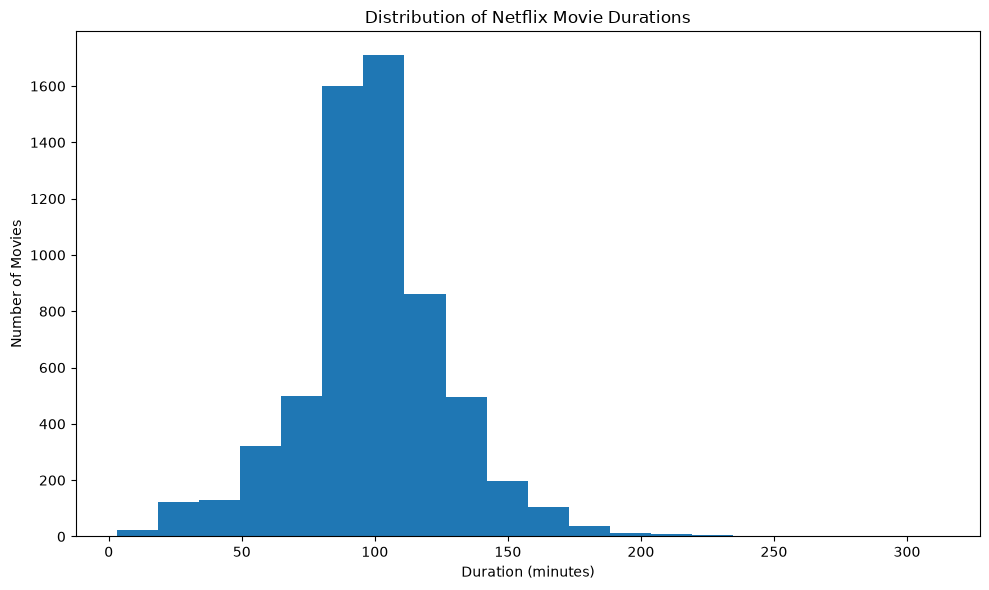

In [38]:
# Movie Duration Analysis

import matplotlib.pyplot as plt

# Select movie records with valid duration values
movie_duration = df.loc[
    df["type"].eq("Movie") & df["duration"].str.contains("min", na=False),
    "duration"
].str.extract(r"(\d+)")[0]

# Convert duration to numeric
movie_duration = pd.to_numeric(movie_duration, errors="coerce").dropna()

print("Movie Duration Statistics:")
display(movie_duration.describe().to_frame(name="Duration (minutes)"))

# Create histogram
plt.figure(figsize=(10, 6))

plt.hist(movie_duration, bins=20)

plt.title("Distribution of Netflix Movie Durations")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")

plt.tight_layout()
plt.show()

## 10. Content Type Trend by Release Year

This analysis compares the number of Movies and TV Shows across release years to understand how the composition of Netflix content varies over time.

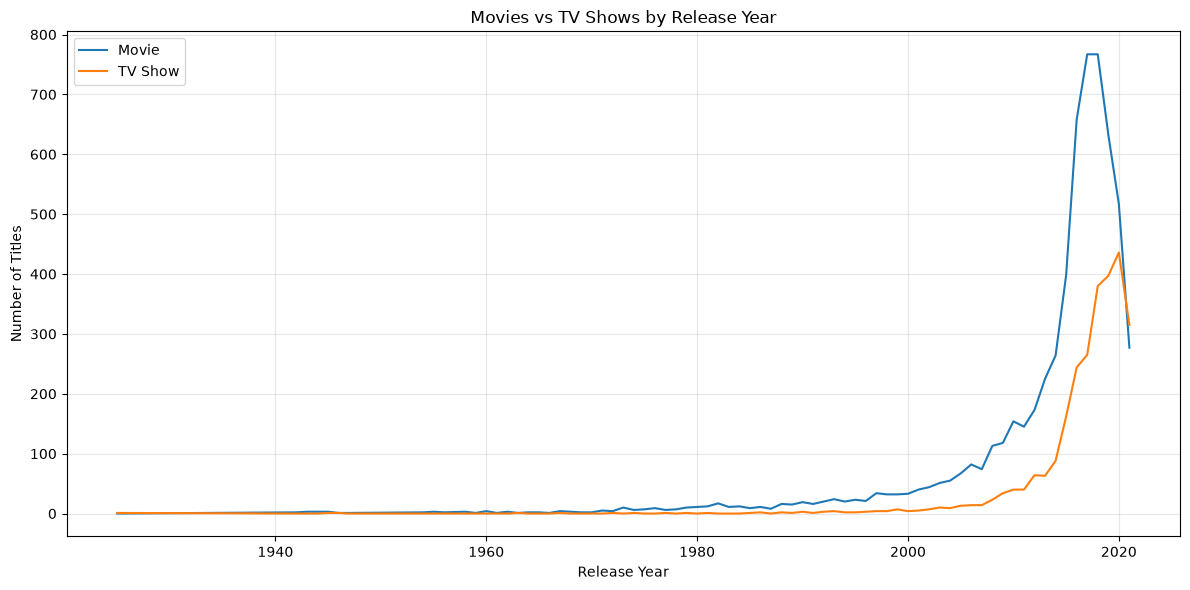

In [39]:
# Movie vs TV Show Trend by Release Year

import matplotlib.pyplot as plt

# Create yearly counts for each content type
content_year = (
    df.groupby(["release_year", "type"])
    .size()
    .unstack(fill_value=0)
)

# Keep only years with available release year values
content_year = content_year.sort_index()

# Plot
plt.figure(figsize=(12, 6))

if "Movie" in content_year.columns:
    plt.plot(
        content_year.index,
        content_year["Movie"],
        label="Movie"
    )

if "TV Show" in content_year.columns:
    plt.plot(
        content_year.index,
        content_year["TV Show"],
        label="TV Show"
    )

plt.title("Movies vs TV Shows by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Top 10 Genres

This analysis identifies the most frequently occurring genres in the Netflix dataset.

Because a title can belong to multiple genres, the genre values are split before counting.

Top 10 Genres:


,Number of Titles
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


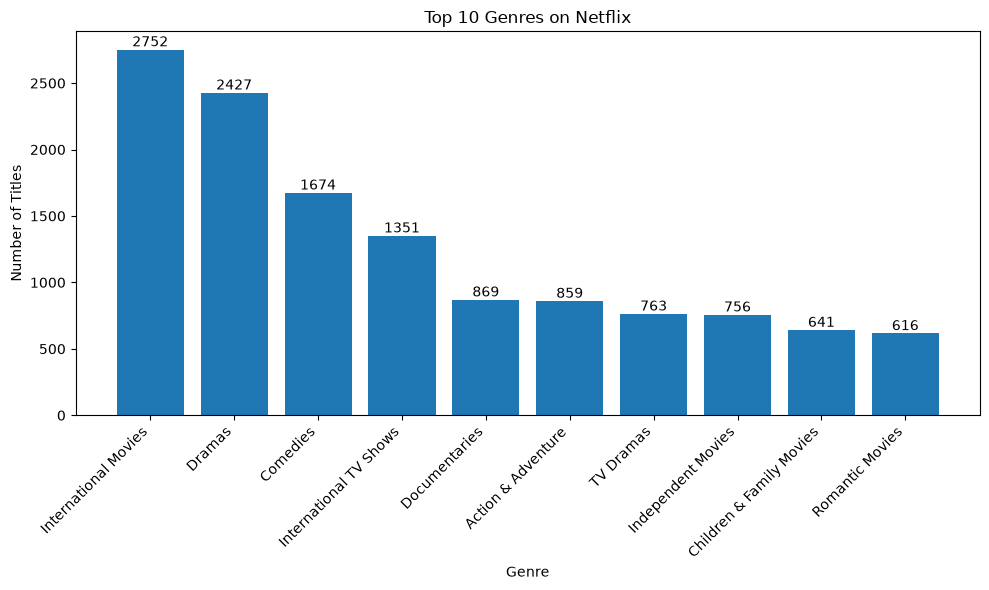

In [40]:
# Top 10 Genres Analysis

import matplotlib.pyplot as plt

# Remove missing values and split multiple genres
genre_series = (
    df["listed_in"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
)

# Count genres
genre_counts = genre_series.value_counts().head(10)

print("Top 10 Genres:")
display(genre_counts.to_frame(name="Number of Titles"))

# Create chart
plt.figure(figsize=(10, 6))

plt.bar(
    genre_counts.index,
    genre_counts.values
)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45, ha="right")

# Add values on bars
for i, value in enumerate(genre_counts.values):
    plt.text(i, value, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.show()

Top 10 Countries by Number of Titles:


,Number of Titles
country,
United States,3690
India,1046
United Kingdom,806
Canada,445
France,393
Japan,318
Spain,232
South Korea,231
Germany,226


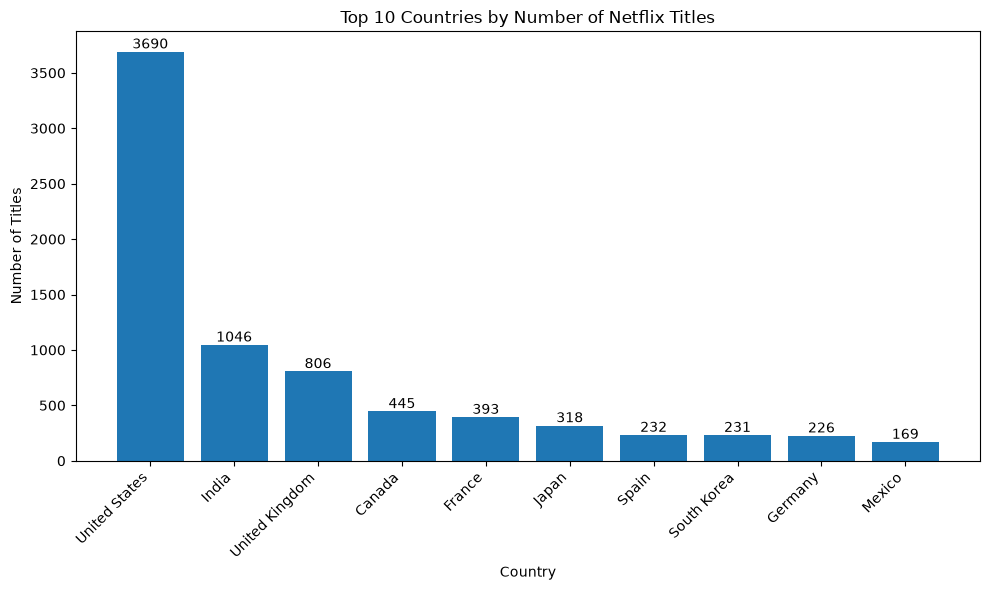

In [41]:
# Top 10 Countries Analysis

country_series = (
    df["country"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
)

country_counts = country_series.value_counts().head(10)

print("Top 10 Countries by Number of Titles:")
display(country_counts.to_frame(name="Number of Titles"))

plt.figure(figsize=(10, 6))

plt.bar(
    country_counts.index,
    country_counts.values
)

plt.title("Top 10 Countries by Number of Netflix Titles")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45, ha="right")

for i, value in enumerate(country_counts.values):
    plt.text(
        i,
        value,
        str(value),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## 12. Netflix Titles Added by Year

This analysis examines how the number of Netflix titles added to the platform changed over time.

The `date_added` column is converted into a date format and grouped by year to identify patterns in Netflix content additions.

Netflix Titles Added by Year:


,Number of Titles
date_added,
2008,2
2009,2
2010,1
2011,13
2012,3
2013,11
2014,24
2015,82
2016,429


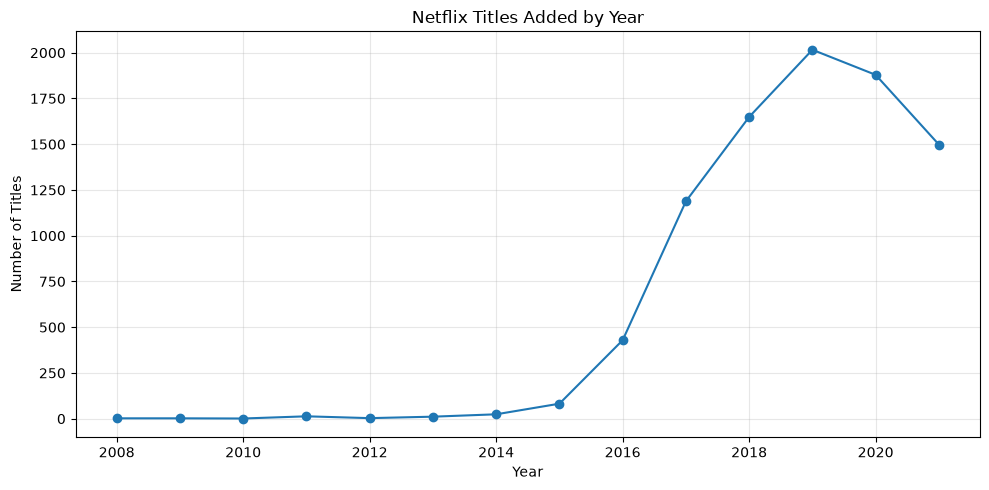

In [44]:
# Netflix Titles Added by Year

import pandas as pd
import matplotlib.pyplot as plt

# Convert date_added to datetime
date_added = pd.to_datetime(df["date_added"], errors="coerce")

# Count titles added each year
titles_added_by_year = (
    date_added.dt.year
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

print("Netflix Titles Added by Year:")
display(
    titles_added_by_year.to_frame(name="Number of Titles")
)

# Plot the trend
plt.figure(figsize=(10, 5))

plt.plot(
    titles_added_by_year.index,
    titles_added_by_year.values,
    marker="o"
)

plt.title("Netflix Titles Added by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Netflix Content Added Over Time

This analysis examines how the number of titles added to Netflix changed over time.

Number of Netflix Titles Added by Year:


,Number of Titles
added_year,
2008,2
2009,2
2010,1
2011,13
2012,3
2013,11
2014,24
2015,82
2016,429


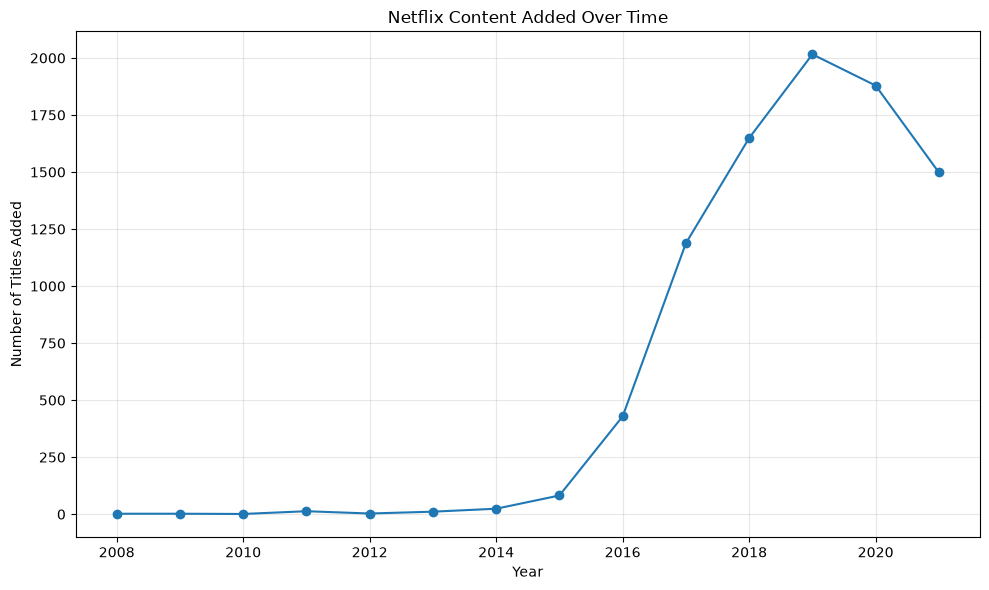

In [42]:
# Netflix Content Added Over Time

df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

added_by_year = (
    df.dropna(subset=["date_added"])
    .assign(added_year=lambda x: x["date_added"].dt.year)
    .groupby("added_year")
    .size()
)

print("Number of Netflix Titles Added by Year:")
display(added_by_year.to_frame(name="Number of Titles"))

plt.figure(figsize=(10, 6))

plt.plot(
    added_by_year.index,
    added_by_year.values,
    marker="o"
)

plt.title("Netflix Content Added Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 14. Movie vs TV Show Percentage Distribution

This analysis compares the proportion of Movies and TV Shows in the Netflix dataset.

Movie vs TV Show Percentage Distribution:


,Percentage
type,
Movie,69.62
TV Show,30.38


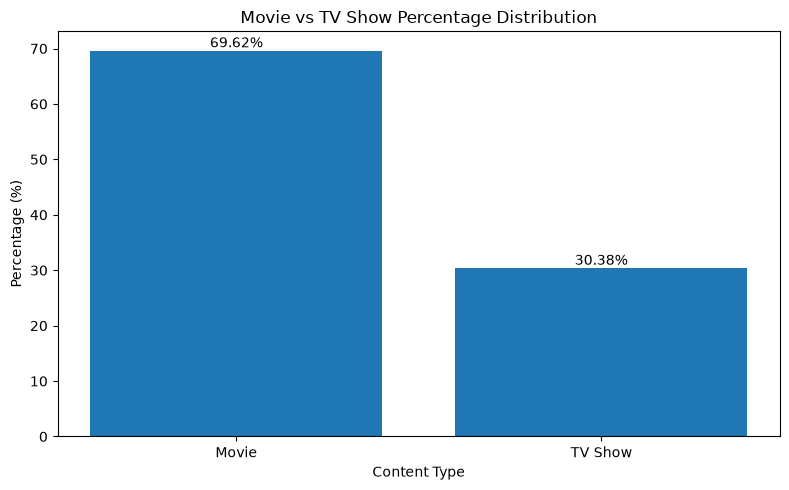

In [43]:
# Movie vs TV Show Percentage Distribution

type_percentage = (
    df["type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Movie vs TV Show Percentage Distribution:")
display(type_percentage.to_frame(name="Percentage"))

plt.figure(figsize=(8, 5))

plt.bar(
    type_percentage.index,
    type_percentage.values
)

plt.title("Movie vs TV Show Percentage Distribution")
plt.xlabel("Content Type")
plt.ylabel("Percentage (%)")

for i, value in enumerate(type_percentage.values):
    plt.text(
        i,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## 15. Key Insights

Based on the exploratory data analysis, the following useful insights were identified:

1. **Movies form the majority of the Netflix catalog.**  
Movies account for approximately 69.62% of the dataset, while TV shows account for approximately 30.38%.

2. **Content production increased significantly in recent years.**  
The number of titles by release year shows a strong increase in content released during the 2010s, with 2018 having the highest number of titles at 1,147.

3. **TV-MA is the most common content rating.**  
TV-MA appears most frequently in the dataset with 3,207 titles, followed by TV-14 with 2,160 titles.

4. **Netflix movies generally have a medium-length runtime.**  
The average movie duration is approximately 99.56 minutes, while the median duration is 98 minutes.

5. **The United States is the most frequently associated country.**  
After splitting multiple-country records, the United States appears in 3,690 title associations, followed by India with 1,046.

6. **International Movies is the most common genre category.**  
International Movies appears most frequently with 2,752 title associations, followed by Dramas with 2,427.

7. **Movie and TV show additions both increased over the later years.**  
The release-year comparison shows a substantial growth in both movies and TV shows during the 2010s and early 2020s.

## 16. Conclusion

The Netflix Movies and TV Shows dataset was explored using Python, Pandas, and Matplotlib.

The exploratory analysis examined content types, release-year trends, ratings, movie durations, genres, countries, and content addition patterns.

The analysis identified several useful patterns, including the distribution of Movies and TV Shows, frequently occurring genres and ratings, movie duration statistics, and changes in Netflix content across different years.

The analysis also included multiple visualizations to make the findings easier to understand.

Overall, the EDA provided a structured understanding of the dataset and identified useful patterns that can support further analysis and dashboard development.